In [13]:
# =============================================================================
# SEGMENTAÇÃO DE ROTAS AÉREAS USANDO K-MEANS (Estratégia Híbrida)
# =============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

In [14]:
# 1. CARREGAMENTO E PREPARAÇÃO
# =============================================================================
# Carregamos apenas colunas essenciais para economizar memória se o dataset for grande
cols = ['ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'DEPARTURE_DELAY', 'DISTANCE']
df = pd.read_csv('data/flights.csv', usecols=cols, low_memory=False)

# Remover nulos críticos
df.dropna(inplace=True)

In [15]:
# 2. ENGENHARIA DE FEATURES: DE "VOOS" PARA "ROTAS"
# =============================================================================
# O K-Means será aplicado nas ROTAS, não nos voos individuais.
# Criamos um perfil para cada rota (Origem -> Destino).

df_rotas = df.groupby(['ORIGIN_AIRPORT', 'DESTINATION_AIRPORT']).agg(
    ATRASO_MEDIO=('DEPARTURE_DELAY', 'mean'),
    DISTANCIA_MEDIA=('DISTANCE', 'mean'),
    FREQUENCIA=('DEPARTURE_DELAY', 'count')
).reset_index()

# Filtro opcional: Manter apenas rotas com um mínimo de voos para evitar outliers irrelevantes
df_rotas = df_rotas[df_rotas['FREQUENCIA'] > 50].copy()

print(f"Total de rotas analisadas: {len(df_rotas)}")

Total de rotas analisadas: 7015


In [16]:
# 3. NORMALIZAÇÃO (STANDARD SCALER)
# =============================================================================
# Essencial: Distância (milhas) e Atraso (minutos) têm escalas muito diferentes.

features = ['ATRASO_MEDIO', 'DISTANCIA_MEDIA', 'FREQUENCIA']
X = df_rotas[features].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [17]:
# 4. ESTRATÉGIA COMBINADA: COTOVELO + SILHOUETTE
# =============================================================================
print("Calculando métricas para k=2 até k=10...")

inertias = []
sil_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = kmeans.fit_predict(X_scaled)

    # 1. Inércia (Para o Cotovelo)
    inertias.append(kmeans.inertia_)

    # 2. Silhouette Score (Para Validação)
    # Nota: O Silhouette é pesado. Se tiver >50k rotas, use sample_size no parâmetro.
    score = silhouette_score(X_scaled, labels)
    sil_scores.append(score)

    print(f"k={k} -> Inércia: {kmeans.inertia_:.0f} | Silhouette: {score:.3f}")

Calculando métricas para k=2 até k=10...
k=2 -> Inércia: 15652 | Silhouette: 0.304
k=3 -> Inércia: 11466 | Silhouette: 0.353
k=4 -> Inércia: 8642 | Silhouette: 0.342
k=5 -> Inércia: 7423 | Silhouette: 0.303
k=6 -> Inércia: 6441 | Silhouette: 0.307
k=7 -> Inércia: 5797 | Silhouette: 0.298
k=8 -> Inércia: 5311 | Silhouette: 0.292
k=9 -> Inércia: 4896 | Silhouette: 0.287
k=10 -> Inércia: 4554 | Silhouette: 0.291


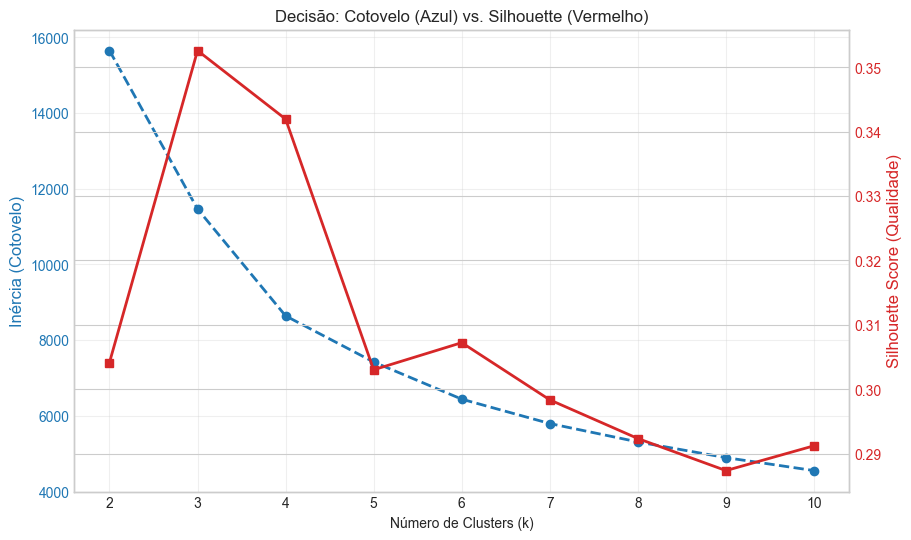

Sugestão baseada puramente no Silhouette: k=3


In [18]:
# 5. VISUALIZAÇÃO DA DECISÃO
# =============================================================================
fig, ax1 = plt.subplots(figsize=(10, 6))

# Eixo Y da Esquerda: Inércia (Cotovelo)
color = 'tab:blue'
ax1.set_xlabel('Número de Clusters (k)')
ax1.set_ylabel('Inércia (Cotovelo)', color=color, fontsize=12)
ax1.plot(k_range, inertias, 'o--', color=color, linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, alpha=0.3)

# Eixo Y da Direita: Silhouette Score
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Silhouette Score (Qualidade)', color=color, fontsize=12)
ax2.plot(k_range, sil_scores, 's-', color=color, linewidth=2)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Decisão: Cotovelo (Azul) vs. Silhouette (Vermelho)')
plt.show()

# Lógica de decisão automática (apenas sugestão)
best_k_sil = k_range[np.argmax(sil_scores)]
print(f"Sugestão baseada puramente no Silhouette: k={best_k_sil}")

In [19]:
# 6. APLICAÇÃO FINAL DO MODELO
# =============================================================================
# Ajuste aqui baseado no gráfico. Vamos assumir k=4 como um bom meio termo.
K_FINAL = 3

kmeans_final = KMeans(n_clusters=K_FINAL, init='k-means++', n_init=10, random_state=42)
df_rotas['CLUSTER'] = kmeans_final.fit_predict(X_scaled)

In [20]:
# 7. INTERPRETAÇÃO DOS CLUSTERS (VOLTANDO Á ESCALA REAL)
# =============================================================================
# O segredo da análise está aqui: ver os centróides na unidade original (minutos/milhas)

centroides_scaled = kmeans_final.cluster_centers_
centroides_real = scaler.inverse_transform(centroides_scaled)

df_centroides = pd.DataFrame(centroides_real, columns=features)
df_centroides['CLUSTER'] = range(K_FINAL)
df_centroides['QTD_ROTAS'] = df_rotas['CLUSTER'].value_counts().sort_index().values

print("\nPERFIL DOS CLUSTERS (Valores Médios):")
print(df_centroides.round(1).to_string(index=False))


PERFIL DOS CLUSTERS (Valores Médios):
 ATRASO_MEDIO  DISTANCIA_MEDIA  FREQUENCIA  CLUSTER  QTD_ROTAS
          5.2            553.1       444.1        0       4105
         11.4           1532.8       518.0        1       2095
         10.5            722.6      3426.4        2        815


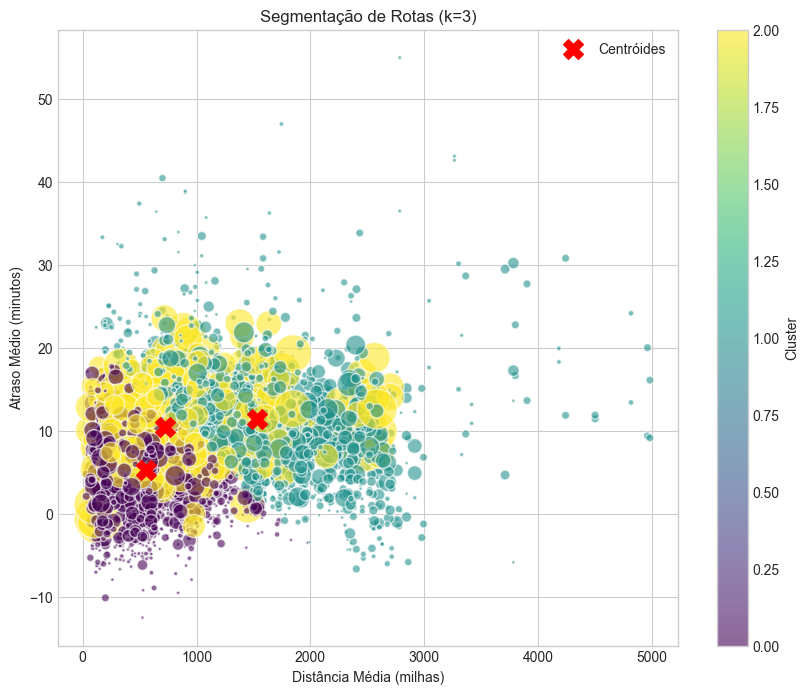

In [21]:
# 8. VISUALIZAÇÃO FINAL (SCATTER PLOT)
# =============================================================================
plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    df_rotas['DISTANCIA_MEDIA'],
    df_rotas['ATRASO_MEDIO'],
    c=df_rotas['CLUSTER'],
    cmap='viridis',
    s=df_rotas['FREQUENCIA'] / 10,  # Tamanho da bolinha = Frequência
    alpha=0.6,
    edgecolors='w'
)

# Plotar Centróides
plt.scatter(centroides_real[:, 1], centroides_real[:, 0], c='red', s=200, marker='X', label='Centróides')

plt.xlabel('Distância Média (milhas)')
plt.ylabel('Atraso Médio (minutos)')
plt.title(f'Segmentação de Rotas (k={K_FINAL})')
plt.colorbar(scatter, label='Cluster')
plt.legend()
plt.show()

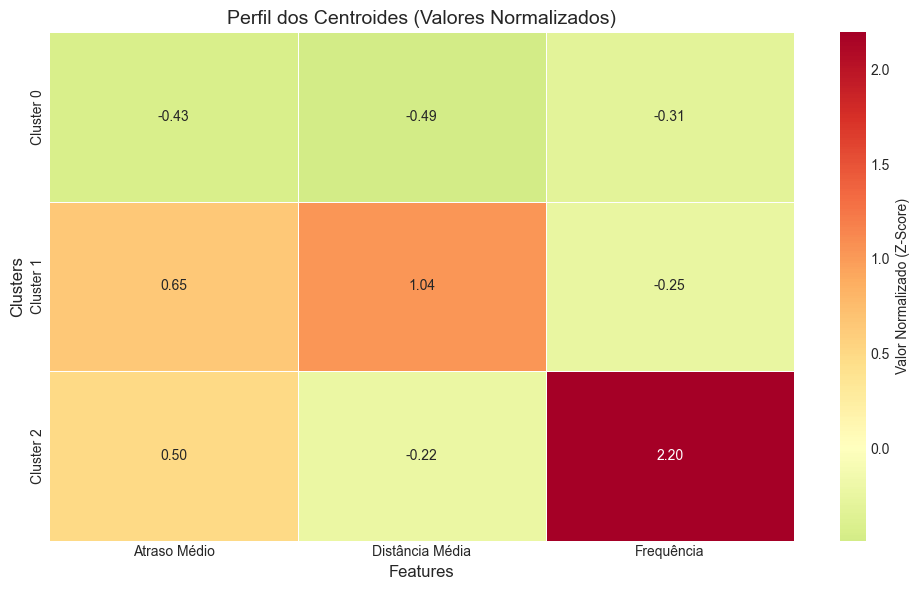


📊 Interpretação do Heatmap:
   - Valores POSITIVOS (vermelho): acima da média geral
   - Valores NEGATIVOS (verde): abaixo da média geral
   - Valores próximos de 0 (amarelo): próximos à média


In [22]:
# 9. HEATMAP NORMALIZADO DOS CENTROIDES
# =============================================================================
# Visualiza o perfil de cada cluster usando os valores normalizados (Z-Score)

df_heatmap = pd.DataFrame(
    centroides_scaled,
    columns=['Atraso Médio', 'Distância Média', 'Frequência'],
    index=[f'Cluster {i}' for i in range(K_FINAL)]
)

plt.figure(figsize=(10, 6))
sns.heatmap(
    df_heatmap,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn_r',
    center=0,
    linewidths=0.5,
    cbar_kws={'label': 'Valor Normalizado (Z-Score)'}
)

plt.title('Perfil dos Centroides (Valores Normalizados)', fontsize=14)
plt.xlabel('Features', fontsize=12)
plt.ylabel('Clusters', fontsize=12)
plt.tight_layout()
plt.show()

print("\n📊 Interpretação do Heatmap:")
print("   - Valores POSITIVOS (vermelho): acima da média geral")
print("   - Valores NEGATIVOS (verde): abaixo da média geral")
print("   - Valores próximos de 0 (amarelo): próximos à média")

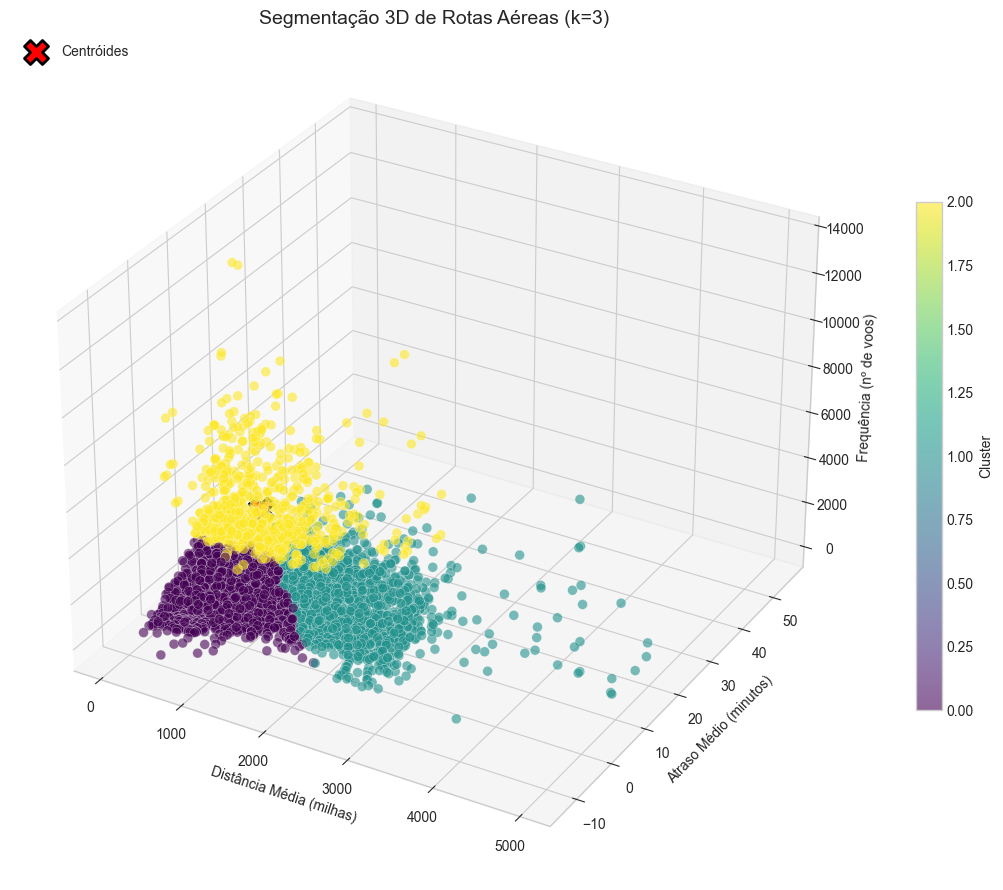

In [23]:
# 10. VISUALIZAÇÃO 3D DOS CLUSTERS
# =============================================================================
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

# Scatter 3D com cores por cluster
scatter = ax.scatter(
    df_rotas['DISTANCIA_MEDIA'],
    df_rotas['ATRASO_MEDIO'],
    df_rotas['FREQUENCIA'],
    c=df_rotas['CLUSTER'],
    cmap='viridis',
    s=50,
    alpha=0.6,
    edgecolors='w',
    linewidth=0.3
)

# Plotar centroides em 3D
ax.scatter(
    centroides_real[:, 1],  # Distância
    centroides_real[:, 0],  # Atraso
    centroides_real[:, 2],  # Frequência
    c='red',
    s=300,
    marker='X',
    label='Centróides',
    edgecolors='black',
    linewidth=2
)

ax.set_xlabel('Distância Média (milhas)', fontsize=10)
ax.set_ylabel('Atraso Médio (minutos)', fontsize=10)
ax.set_zlabel('Frequência (nº de voos)', fontsize=10)
ax.set_title(f'Segmentação 3D de Rotas Aéreas (k={K_FINAL})', fontsize=14)

plt.colorbar(scatter, label='Cluster', shrink=0.6)
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

In [24]:
# 11. EXEMPLOS DETALHADOS DE ROTAS POR CLUSTER
# =============================================================================
print("=" * 80)
print("EXEMPLOS DETALHADOS DE ROTAS POR CLUSTER")
print("=" * 80)

for cluster_id in sorted(df_rotas['CLUSTER'].unique()):
    cluster_data = df_rotas[df_rotas['CLUSTER'] == cluster_id]
    stats = df_centroides[df_centroides['CLUSTER'] == cluster_id].iloc[0]

    # Classificação do cluster
    delay_level = "ALTO" if stats['ATRASO_MEDIO'] > 10 else "MODERADO" if stats['ATRASO_MEDIO'] > 5 else "BAIXO"
    dist_level = "LONGA" if stats['DISTANCIA_MEDIA'] > 1500 else "MÉDIA" if stats['DISTANCIA_MEDIA'] > 800 else "CURTA"
    freq_level = "ALTA" if stats['FREQUENCIA'] > 500 else "MÉDIA" if stats['FREQUENCIA'] > 200 else "BAIXA"

    print(f"\n{'='*80}")
    print(f"📍 CLUSTER {cluster_id} - {int(stats['QTD_ROTAS'])} rotas")
    print(f"{'='*80}")
    print(f"   Perfil: Distância {dist_level} | Atraso {delay_level} | Frequência {freq_level}")
    print(f"   Médias: {stats['DISTANCIA_MEDIA']:.0f} mi | {stats['ATRASO_MEDIO']:.1f} min | {stats['FREQUENCIA']:.0f} voos")
    print(f"\n   🔹 Top 5 rotas mais frequentes:")

    top_rotas = cluster_data.nlargest(5, 'FREQUENCIA')
    for i, (_, row) in enumerate(top_rotas.iterrows(), 1):
        print(f"      {i}. {row['ORIGIN_AIRPORT']} → {row['DESTINATION_AIRPORT']}: "
              f"{int(row['FREQUENCIA']):,} voos | "
              f"{row['DISTANCIA_MEDIA']:.0f} mi | "
              f"atraso {row['ATRASO_MEDIO']:.1f} min")

    print(f"\n   🔸 Top 3 rotas com maior atraso:")
    top_atraso = cluster_data.nlargest(3, 'ATRASO_MEDIO')
    for i, (_, row) in enumerate(top_atraso.iterrows(), 1):
        print(f"      {i}. {row['ORIGIN_AIRPORT']} → {row['DESTINATION_AIRPORT']}: "
              f"atraso {row['ATRASO_MEDIO']:.1f} min | "
              f"{int(row['FREQUENCIA']):,} voos")

print(f"\n{'='*80}")
print("RESUMO FINAL")
print("=" * 80)
print(df_centroides[['CLUSTER', 'ATRASO_MEDIO', 'DISTANCIA_MEDIA', 'FREQUENCIA', 'QTD_ROTAS']].round(1).to_string(index=False))

EXEMPLOS DETALHADOS DE ROTAS POR CLUSTER

📍 CLUSTER 0 - 4105 rotas
   Perfil: Distância CURTA | Atraso MODERADO | Frequência MÉDIA
   Médias: 553 mi | 5.2 min | 444 voos

   🔹 Top 5 rotas mais frequentes:
      1. PIT → CLT: 2,400 voos | 366 mi | atraso 1.4 min
      2. SLC → PDX: 2,336 voos | 630 mi | atraso 2.6 min
      3. IAH → BTR: 2,277 voos | 253 mi | atraso 4.3 min
      4. BTR → IAH: 2,275 voos | 253 mi | atraso 3.5 min
      5. SAN → SLC: 2,261 voos | 626 mi | atraso 1.6 min

   🔸 Top 3 rotas com maior atraso:
      1. ROC → LGA: atraso 17.7 min | 173 voos
      2. 12129 → 13487: atraso 17.6 min | 53 voos
      3. CEC → SFO: atraso 17.4 min | 174 voos

📍 CLUSTER 1 - 2095 rotas
   Perfil: Distância LONGA | Atraso ALTO | Frequência ALTA
   Médias: 1533 mi | 11.4 min | 518 voos

   🔹 Top 5 rotas mais frequentes:
      1. LAX → MIA: 3,012 voos | 2342 mi | atraso 6.7 min
      2. MIA → LAX: 3,011 voos | 2342 mi | atraso 15.6 min
      3. LAX → OGG: 2,702 voos | 2486 mi | atraso 10